# Fifa World Cup (1974-2022) - Exploratory Data Analysis

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading the Dataset:

In [175]:
df = pd.read_csv('fifa_world_cup_enhanced_1974_2022.csv')

## Phase 1 - Understanding the Data

### Shape:

In [176]:
df.shape

(43, 38)

There are 43 rows and 38 columns in the dataset.

In [177]:
df.head()

,match_id,year,date,stage,home_team,away_team,home_goals,away_goals,winner,goal_difference,...,venue,city,referee,home_goals_detail,away_goals_detail,penalty_shootout,penalty_home,penalty_away,tournament_format,host_nations
0,WC-1974-001,1974,1974-06-13,Group 1,Brazil,Yugoslavia,0,0,Draw,0,...,Waldstadion,Frankfurt,Károly Palotai (Hungary),NaN,Jovan Aćimović (60'),No,NaN,NaN,16,West Germany
1,WC-1974-038,1974,1974-07-07,Final,West Germany,Netherlands,2,1,West Germany,1,...,Olympiastadion,Munich,John Taylor (England),"Paul Breitner (25' pen), Gerd Müller (43')",Johan Neeskens (2' pen),No,NaN,NaN,16,West Germany
2,WC-1974-008,1974,1974-06-18,Group 2,Yugoslavia,Zaire,9,0,Yugoslavia,9,...,Parkstadion,Gelsenkirchen,Omar Delgado (Colombia),"Dušan Bajević (8', 30', 81'), Dragan Džajić (1...",NaN,No,NaN,NaN,16,West Germany
3,WC-1974-012,1974,1974-06-22,Group A,Netherlands,Brazil,2,0,Netherlands,2,...,Westfalenstadion,Dortmund,Kurt Tschenscher (West Germany),"Johan Neeskens (50'), Johan Cruyff (65')",NaN,No,NaN,NaN,16,West Germany
4,WC-1978-038,1978,1978-06-25,Final,Argentina,Netherlands,3,1,Argentina,2,...,Estadio Monumental,Buenos Aires,Sergio Gonella (Italy),"Mario Kempes (38', 105'), Daniel Bertoni (115')",Dirk Nanninga (82'),Yes (AET),NaN,NaN,16,Argentina


### Data Types

In [178]:
df.dtypes

match_id                object
year                     int64
date                    object
stage                   object
home_team               object
away_team               object
home_goals               int64
away_goals               int64
winner                  object
goal_difference          int64
total_goals              int64
home_xg                float64
away_xg                float64
possession_home          int64
possession_away          int64
shots_home               int64
shots_away               int64
shots_ontarget_home      int64
shots_ontarget_away      int64
corners_home             int64
corners_away             int64
fouls_home               int64
fouls_away               int64
yellow_cards_home        int64
yellow_cards_away        int64
red_cards_home           int64
red_cards_away           int64
attendance               int64
venue                   object
city                    object
referee                 object
home_goals_detail       object
away_goa

### Replacing 'date' Type

In [147]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype

dtype('<M8[ns]')

### Converting `tournament_format` to Categorical (str)

In [148]:
df['tournament_format']= df['tournament_format'].astype('str').map({"16": "16-team era", "24":"24-team era","32":"32-team era"})

Two dtype issues identified:
- `date` was stored as `object` (string) — converted to `datetime64`
- `tournament_format` contains values 16, 24, 32 representing historical team count eras, not true numeric data — converted to categorical labels

### Missing Values

In [149]:
df.isnull().sum()

match_id                0
year                    0
date                    0
stage                   0
home_team               0
away_team               0
home_goals              0
away_goals              0
winner                  0
goal_difference         0
total_goals             0
home_xg                 0
away_xg                 0
possession_home         0
possession_away         0
shots_home              0
shots_away              0
shots_ontarget_home     0
shots_ontarget_away     0
corners_home            0
corners_away            0
fouls_home              0
fouls_away              0
yellow_cards_home       0
yellow_cards_away       0
red_cards_home          0
red_cards_away          0
attendance              0
venue                   0
city                    0
referee                 0
home_goals_detail       6
away_goals_detail      15
penalty_shootout        0
penalty_home           34
penalty_away           34
tournament_format       0
host_nations            0
dtype: int64

Only penalty records are missing, as penalties aren't guarantueed to happen in every game.

### Descriptive Statistical Analysis

In [150]:
df.describe()

,year,date,home_goals,away_goals,goal_difference,total_goals,home_xg,away_xg,possession_home,possession_away,...,corners_away,fouls_home,fouls_away,yellow_cards_home,yellow_cards_away,red_cards_home,red_cards_away,attendance,penalty_home,penalty_away
count,43.000000,43,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,...,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,9.000000,9.000000
mean,2002.000000,2002-08-01 15:04:11.162790656,2.302326,0.906977,1.395349,3.209302,2.069767,1.225581,53.930233,46.069767,...,4.465116,15.534884,18.534884,2.255814,3.069767,0.023256,0.069767,64174.209302,3.555556,2.888889
min,1974.000000,1974-06-13 00:00:00,0.000000,0.000000,-2.000000,0.000000,0.800000,0.100000,38.000000,29.000000,...,0.000000,9.000000,12.000000,0.000000,1.000000,0.000000,0.000000,23000.000000,1.000000,2.000000
25%,1988.000000,1988-07-01 00:00:00,1.000000,0.000000,0.000000,2.000000,1.550000,0.850000,48.000000,41.500000,...,3.000000,13.000000,15.500000,1.500000,2.000000,0.000000,0.000000,44041.500000,3.000000,2.000000
50%,2002.000000,2002-06-30 00:00:00,2.000000,1.000000,1.000000,3.000000,1.900000,1.100000,53.000000,47.000000,...,5.000000,16.000000,18.000000,2.000000,3.000000,0.000000,0.000000,63000.000000,4.000000,3.000000
75%,2018.000000,2018-06-28 12:00:00,3.000000,1.000000,2.000000,4.000000,2.300000,1.650000,58.500000,52.000000,...,6.000000,17.500000,22.000000,3.000000,4.000000,0.000000,0.000000,79005.500000,4.000000,3.000000
max,2022.000000,2022-12-18 00:00:00,10.000000,3.000000,9.000000,11.000000,5.500000,2.800000,71.000000,62.000000,...,9.000000,21.000000,28.000000,5.000000,8.000000,1.000000,1.000000,114600.000000,5.000000,5.000000
std,16.653328,NaN,2.220413,0.867782,2.401780,2.366011,0.953573,0.579036,7.917417,7.917417,...,2.130826,3.119439,3.737512,1.216807,1.316477,0.152499,0.257770,21797.995130,1.130388,1.054093


- `home_goals` max of 10 is a real outlier pulling the mean above the median
- `attendance` ranges from 23,000 to 114,600
- `red_cards` 25th, 50th and 75th percentiles are all 0, most matches have zero red cards
- `goal_difference` minimum is -2, confirming away team victories exist in the data

### Categorical Columns Values

In [151]:
df['stage'].value_counts()

stage
Final            13
Semi-final        7
Quarter-final     6
Group H           3
Group A           2
Group B           2
Round of 16       2
Group F           2
Group 1           1
Group 2           1
Group 3           1
Group C           1
Group D           1
Group E           1
Name: count, dtype: int64

In [152]:
df['winner'].value_counts()

winner
Argentina       8
Brazil          5
West Germany    4
Netherlands     4
France          4
Germany         3
Draw            2
Italy           2
Croatia         2
Hungary         1
Yugoslavia      1
Spain           1
Switzerland     1
Uruguay         1
Mexico          1
Japan           1
Morocco         1
South Korea     1
Name: count, dtype: int64

In [153]:
df['tournament_format'].value_counts()

tournament_format
32-team era    28
24-team era     9
16-team era     6
Name: count, dtype: int64

In [154]:
df['host_nations'].value_counts()

host_nations
Qatar                9
West Germany         4
France               4
Brazil               4
Spain                3
South Korea/Japan    3
South Africa         3
Russia               3
Argentina            2
Mexico               2
Italy                2
USA                  2
Germany              2
Name: count, dtype: int64

- **stage**: 13 Finals entries across multiple World Cups, one per tournament
- **winner**: Argentina leads with 8 wins. "Draw" entries indicate matches decided by penalties
- **tournament_format**: 32-team era has the most matches (28) as it has been in place since 1998
- **host_nations**: Qatar shows 9 entries reflecting more tracked matches from the 2022 tournament

## Phase 2 - Univariate Analysis
We will look at each column individually

### Goals

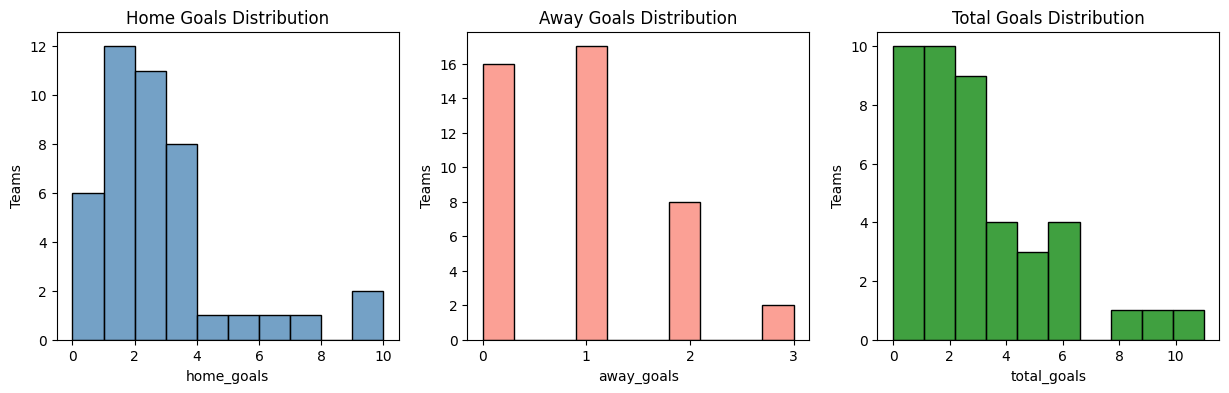

In [155]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
sns.histplot(df['home_goals'], bins=10, ax=axes[0], color='steelblue')
axes[0].set_title('Home Goals Distribution')
axes[0].set_ylabel('Teams')
sns.histplot(df['away_goals'], bins=10, ax=axes[1], color='salmon')
axes[1].set_title('Away Goals Distribution')
axes[1].set_ylabel('Teams')
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
sns.histplot(df['total_goals'], bins=10, ax=axes[2], color='green')
axes[2].set_title('Total Goals Distribution')
axes[2].set_ylabel('Teams')
plt.show()

### Goal Distributions
- Home goals are right-skewed, peaking at 1–2, with historic outliers beyond 8
- Away teams are heavily concentrated at 0–1 goals — finals are hard to win from the away side
- Most finals produce 2–3 total goals combined; high-scoring matches are outliers from early eras
- Discrete count data should always use integer x-axis ticks

### Attendance

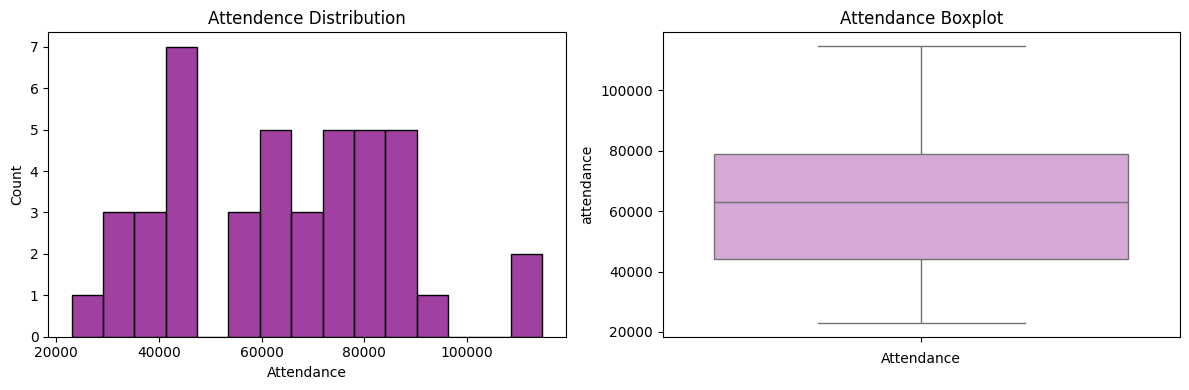

In [156]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['attendance'], bins=15, ax=axes[0], color='purple')
axes[0].set_title('Attendence Distribution')
axes[0].set_xlabel('Attendance')
sns.boxplot(y=df['attendance'], ax=axes[1], color='plum')
axes[1].set_title('Attendance Boxplot')
axes[1].set_xlabel('Attendance')
plt.tight_layout()
plt.show()


### Attendance Distribution
- Distribution is bimodal — two clusters around 40,000 and 60,000–80,000
- Likely reflects smaller stadiums in early World Cup eras vs large modern venues
- No statistical outliers detected by the IQR rule despite the wide range (23,000–114,600)

### Fouls, Yellow Cards & Possession

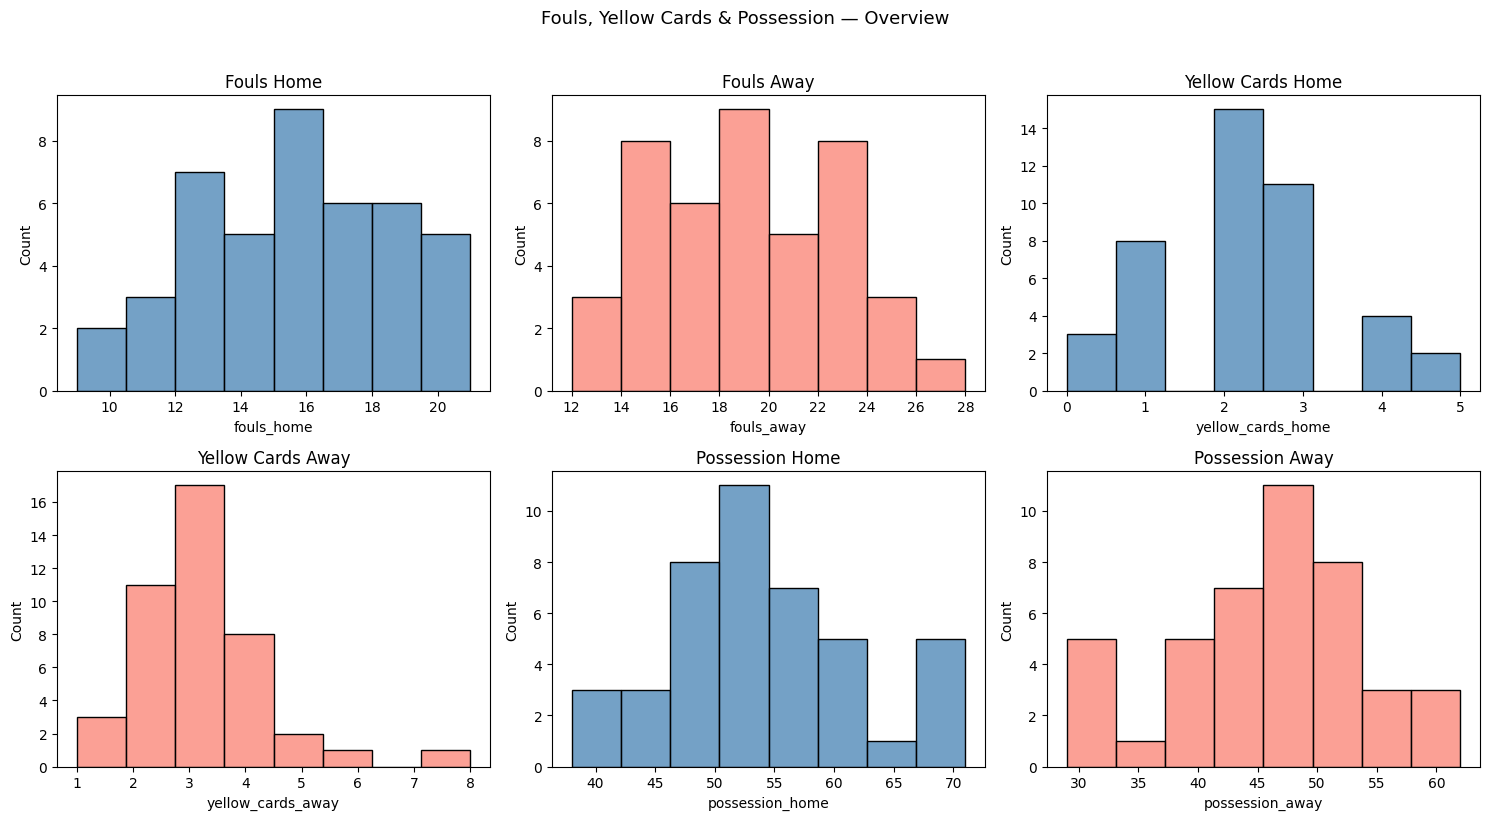

In [157]:
fig, axes = plt.subplots(2,3,figsize=(15,8))
sns.histplot(df['fouls_home'], ax=axes[0][0], color='steelblue', bins=8)
axes[0][0].set_title('Fouls Home')

sns.histplot(df['fouls_away'], ax=axes[0][1], color='salmon', bins=8)
axes[0][1].set_title('Fouls Away')

sns.histplot(df['yellow_cards_home'], ax=axes[0][2], color='steelblue', bins=8)
axes[0][2].set_title('Yellow Cards Home')

sns.histplot(df['yellow_cards_away'], ax=axes[1][0], color='salmon', bins=8)
axes[1][0].set_title('Yellow Cards Away')

sns.histplot(df['possession_home'], ax=axes[1][1], color='steelblue', bins=8)
axes[1][1].set_title('Possession Home')

sns.histplot(df['possession_away'], ax=axes[1][2], color='salmon', bins=8)
axes[1][2].set_title('Possession Away')

plt.suptitle('Fouls, Yellow Cards & Possession — Overview', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### Fouls, Yellow Cards & Possession — Overview
- Away teams commit more fouls and receive more yellow cards than home teams on average
- Possession home is roughly bell-shaped, centered around 50–55%
- Possession away is slightly right-skewed, shifted lower (29–62% range vs 38–71% for home)
- Home sides consistently control more possession — the entire distribution is shifted right
- Since possession always sums to 100%, possession_home and possession_away are redundant;
  only one is needed for further analysis

## Phase 3 - Multivariate Analysis
We will simutaneously analyze multiple columns are compare them.

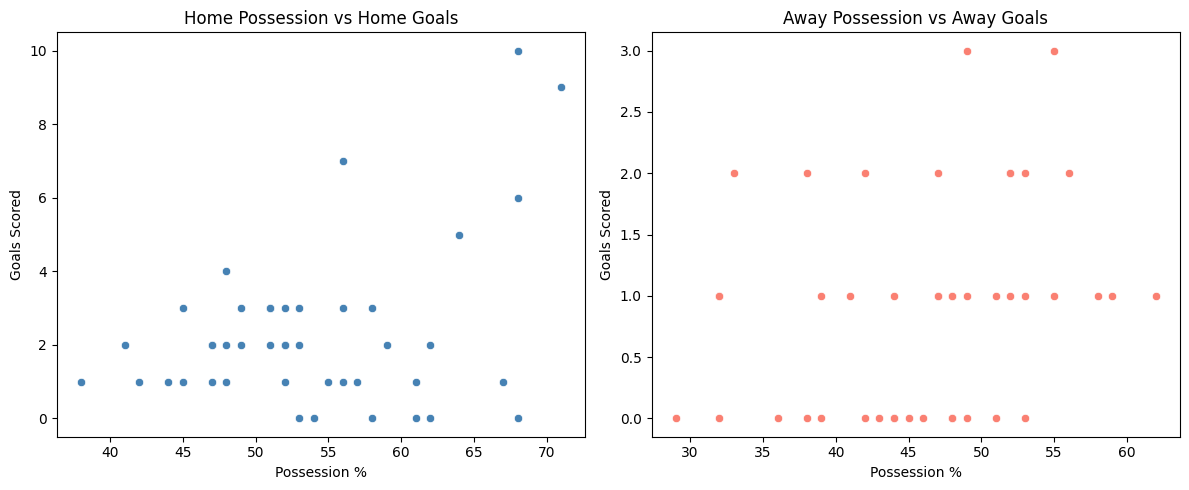

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='possession_home', y='home_goals', ax=axes[0], color='steelblue')
axes[0].set_title('Home Possession vs Home Goals')
axes[0].set_xlabel('Possession %')
axes[0].set_ylabel('Goals Scored')
sns.scatterplot(data=df, x='possession_away', y='away_goals', ax=axes[1], color='salmon')
axes[1].set_title('Away Possession vs Away Goals')
axes[1].set_xlabel('Possession %')
axes[1].set_ylabel('Goals Scored')
plt.tight_layout()
plt.show()

In [159]:
home_corr = df['possession_home'].corr(df['home_goals'])
away_corr = df['possession_away'].corr(df['away_goals'])
print(f"Home possession vs home goals correlation: {home_corr:.2f}")
print(f"Away possession vs away goals correlation: {away_corr:.2f}")

Home possession vs home goals correlation: 0.37
Away possession vs away goals correlation: 0.27


### Possession vs Goals
- Scatter plots show no clear linear relationship between possession and goals for either side
- Correlation coefficients: Home = 0.37, Away = 0.27 — both weak
- Higher possession does not reliably predict more goals in World Cup finals
- Small sample size (43 matches) means even weak correlations should be interpreted cautiously
- This aligns with modern football analytics: possession is not a direct measure of attacking threat

### Shots on Target vs Goals Scored

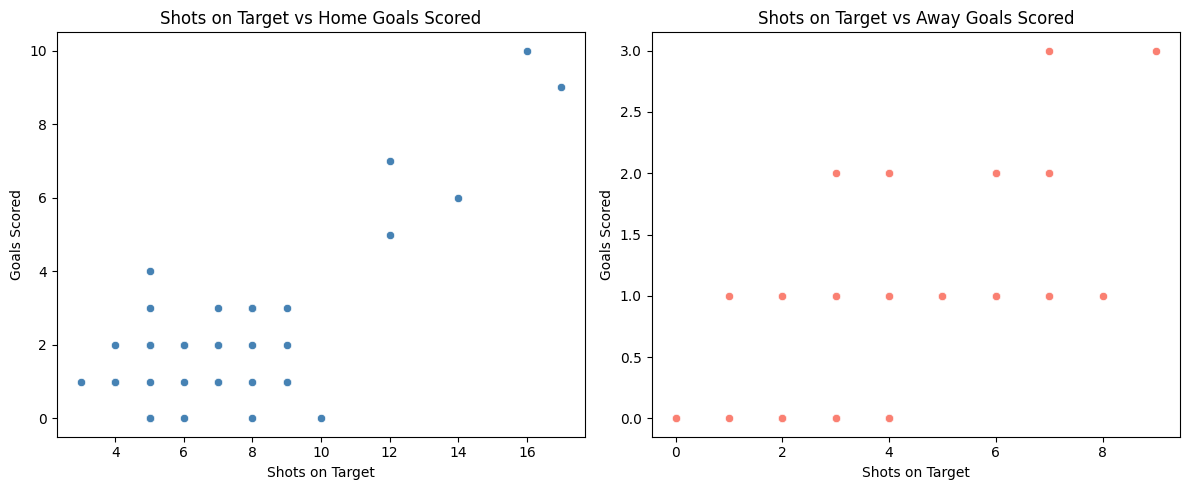

In [160]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.scatterplot(data=df,x='shots_ontarget_home',y='home_goals',ax=axes[0],color='steelblue')
axes[0].set_title('Shots on Target vs Home Goals Scored')
axes[0].set_xlabel('Shots on Target')
axes[0].set_ylabel('Goals Scored')
sns.scatterplot(data=df,x='shots_ontarget_away',y='away_goals',ax=axes[1],color='salmon')
axes[1].set_title('Shots on Target vs Away Goals Scored')
axes[1].set_xlabel('Shots on Target')
axes[1].set_ylabel('Goals Scored')
plt.tight_layout()
plt.show()

In [161]:
home_corr = df['shots_ontarget_home'].corr(df['home_goals'])
away_corr = df['shots_ontarget_away'].corr(df['away_goals'])
print(f"Home shots on target vs home goals correlation: {home_corr:.2f}")
print(f"Away shots on target vs away goals correlation: {away_corr:.2f}")

Home shots on target vs home goals correlation: 0.78
Away shots on target vs away goals correlation: 0.68



- Strong positive correlation for home teams (0.78) — shots on target is an excellent predictor of goals
- Moderate-to-strong correlation for away teams (0.68) — relationship holds but with more variance
- Both values significantly higher than possession correlations (0.37 and 0.27)
- Shots on target is a universally strong metric regardless of home/away status
- Possession tells you who controls the ball; shots on target tells you who is actually threatening to score

### Goals scored over the years and by tournament era

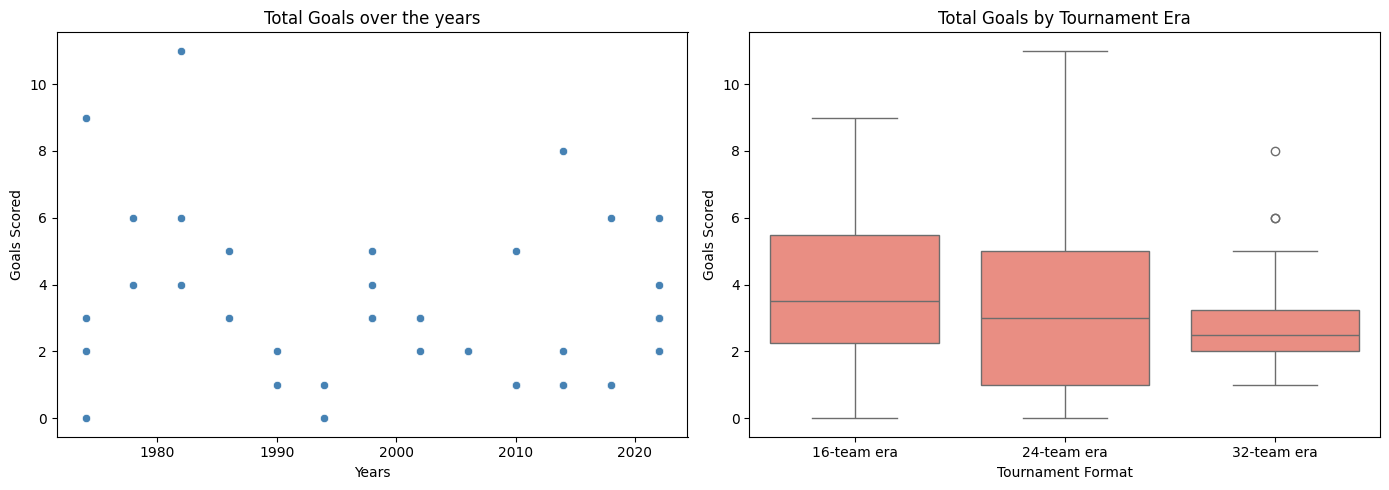

In [170]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.scatterplot(data=df, x='year', y='total_goals',ax=axes[0],color='steelblue')
axes[0].set_title('Total Goals over the years')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Goals Scored')
sns.boxplot(data=df, x='tournament_format', y='total_goals', ax=axes[1], color='salmon')
axes[1].set_title('Total Goals by Tournament Era')
axes[1].set_xlabel('Tournament Format')
axes[1].set_ylabel('Goals Scored')
plt.tight_layout()
plt.show()

### Scoring Trends Across Eras
- Pre-1990 games were volatile and high-scoring, with outliers reaching 9–11 goals
- Post-1990 saw a dramatic compression — most games settled at 3 goals or fewer
- 16-team era: highest median (~3.5 goals), high floor
- 24-team era: most unpredictable — widest spread, transition period
- 32-team era: lowest median (~2.5 goals), tightly compressed between 2–3 goals
- Modern games are significantly more defensive and standardized than early era matches
- Trend reflects global tactical evolution: professional defending, pressing, and higher stakes

### Home vs Away Performance

In [163]:
home_wins = (df['winner'] == df['home_team']).sum()
away_wins = (df['winner'] == df['away_team']).sum()
draws = (df['winner'] == 'Draw').sum()
results = pd.Series({'Home Wins': home_wins, 'Away Wins': away_wins, 'Draws': draws})
results

Home Wins    32
Away Wins     9
Draws         2
dtype: int64

/var/folders/xc/2w2cs51x3rn6wz9z0ppw8jnc0000gn/T/ipykernel_1790/1855386811.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results.index, y=results.values, palette=['steelblue', 'salmon', 'gray'],ax=axes)


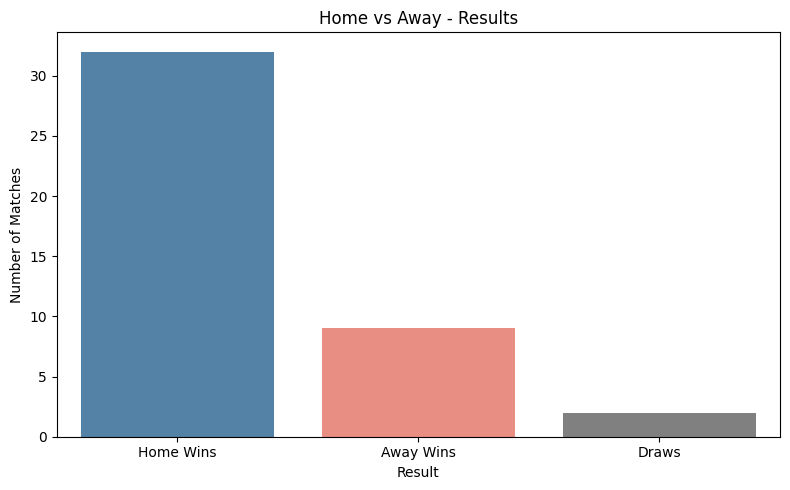

In [171]:
fig, axes = plt.subplots(figsize=(8,5))
sns.barplot(x=results.index, y=results.values, palette=['steelblue', 'salmon', 'gray'],ax=axes)
axes.set_title('Home vs Away - Results')
axes.set_xlabel('Result')
axes.set_ylabel('Number of Matches')
plt.tight_layout()
plt.show()

In [165]:
host_is_home = df[df['home_team'] == df['host_nations']].shape[0]
print(f"Matches where home team = host nation: {host_is_home} out of {len(df)}")

Matches where home team = host nation: 5 out of 43


### Home vs Away Performance
- Home teams won 32 matches vs 9 for away teams — a 3.5x disparity
- Initial interpretation suggested massive home advantage
- However, only 5 out of 43 matches had the literal host nation as the home team
- "Home" designation is almost entirely a bracket assignment, not geographic
- The disparity reflects stronger teams being seeded as "home" in the bracket

## Phase 4 - Domain Specific Questions

### Which nations dominate across all key World Cup stages in this dataset.

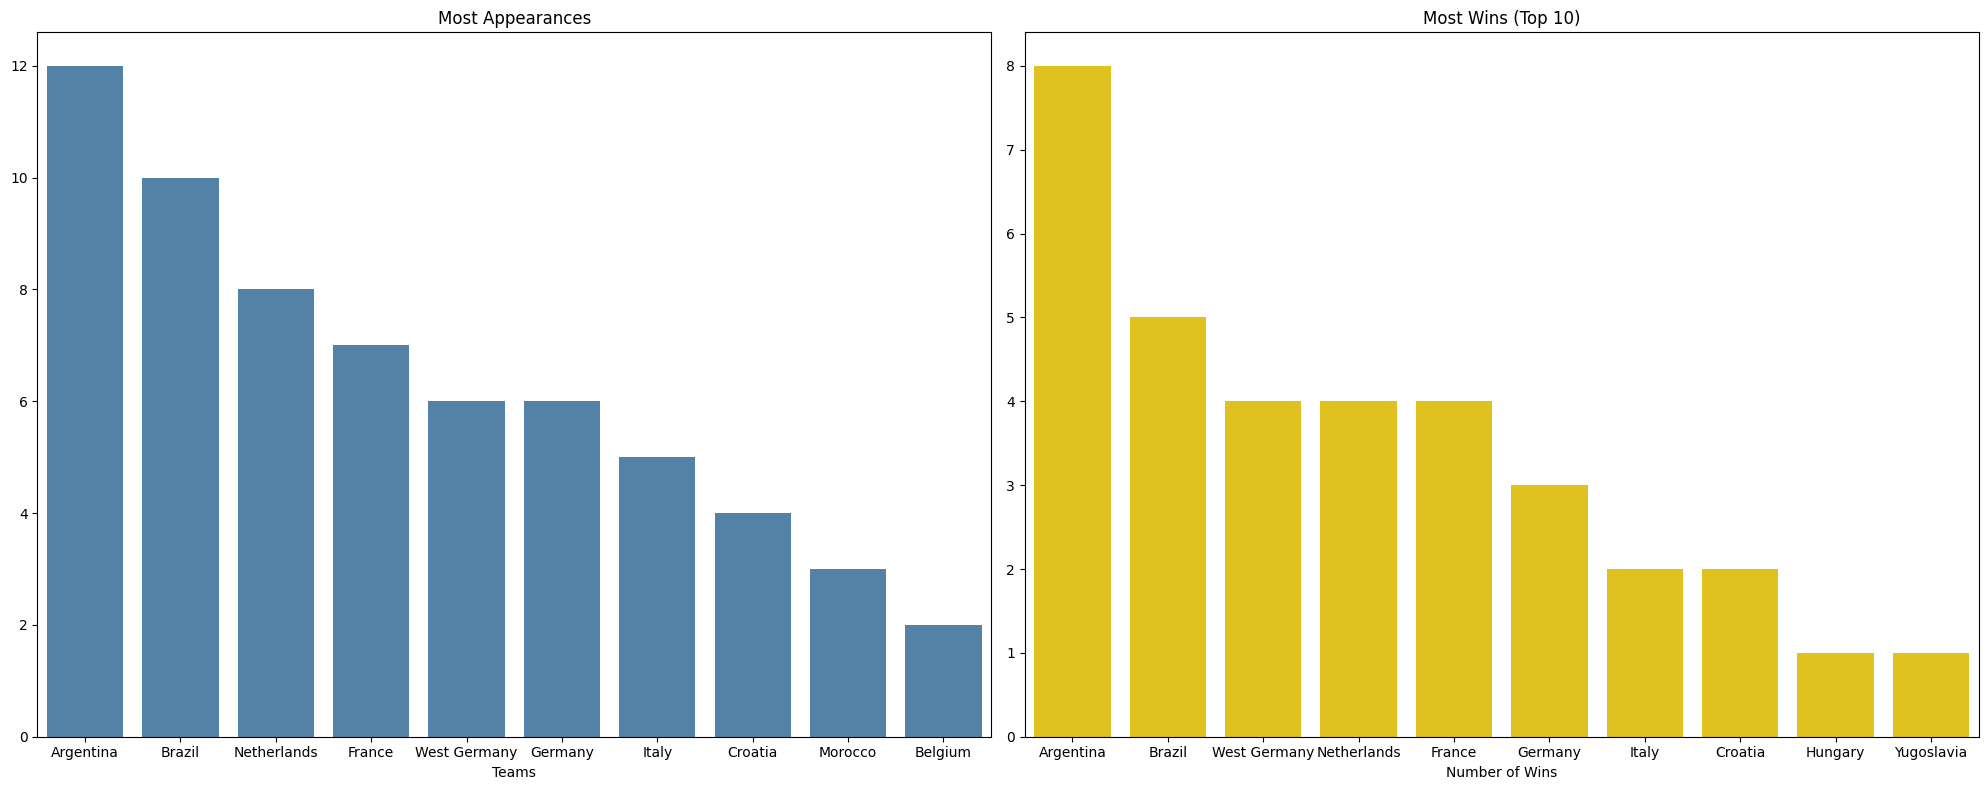

In [166]:
appearances = pd.concat((df['home_team'],df['away_team'])).value_counts().head(10)
wins = df[df['winner'] != 'Draw']['winner'].value_counts().head(10)
fig, axes = plt.subplots(1,2,figsize=(20,8))
sns.barplot(x=appearances.index, y=appearances.values, ax=axes[0], color='steelblue')
axes[0].set_title('Most Appearances')
axes[0].set_xlabel('Teams')
sns.barplot(x=wins.index,y=wins.values,ax=axes[1],color='gold')
axes[1].set_title('Most Wins (Top 10)')
axes[1].set_xlabel('Number of Wins')
plt.tight_layout()
plt.show()

In [167]:
# Filter to only the actual championship final
actual_finals = df[df['stage'] == 'Final']
print(actual_finals['winner'].value_counts())

winner
Argentina       3
West Germany    2
Italy           2
Brazil          2
France          2
Spain           1
Germany         1
Name: count, dtype: int64


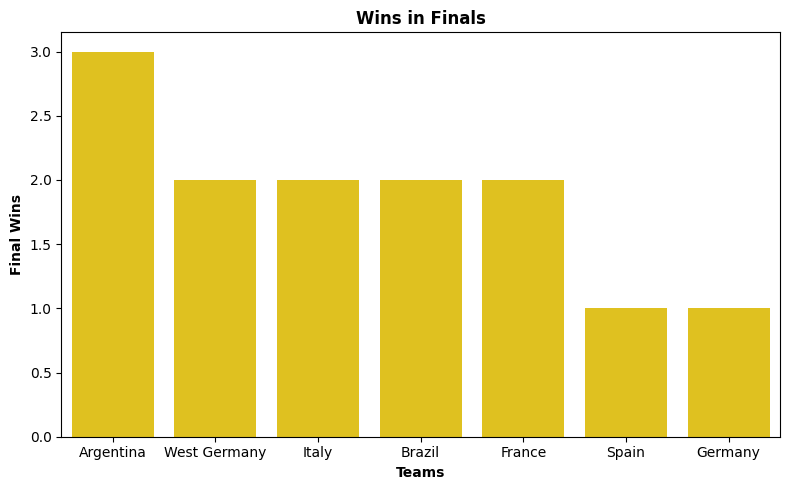

In [173]:
final_wins = actual_finals['winner'].value_counts()
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=final_wins.index,y=final_wins.values,ax=ax,color='gold')
ax.set_title('Wins in Finals', fontweight='bold')
ax.set_xlabel('Teams', fontweight='bold')
ax.set_ylabel('Final Wins',fontweight='bold')
plt.tight_layout()
plt.show()

#### Dataset Scope Note
This dataset covers matches from **1974 to 2022** and includes multiple stages
(Group, Round of 16, Quarter-finals, Semi-finals, and Finals).
It does not represent complete all-time World Cup records — Brazil's 1958, 1962,
and 1970 titles for example fall outside this dataset's range.

#### Across All 43 Matches
- Argentina leads with 12 appearances and 8 wins — consistent dominance at every stage
- Brazil follows with 10 appearances and 5 wins
- Netherlands have 8 appearances and 4 wins — high volume but inconsistent conversion
- West Germany show strong efficiency: 6 appearances, 4 wins

#### In the 13 Championship Finals Only
- Argentina: 3 wins — dominant at every level
- Brazil, France, West Germany, Italy: 2 wins each
- Netherlands: 0 championship final wins despite winning 4 matches across other stages
- Confirms their historical reputation — dangerous throughout the tournament, yet to lift the trophy

#### Key Insight
The all-stages view and the finals-only view tell different stories.
Brazil looks more dominant across stages but less clinical in the actual final.
The Netherlands are exposed as a heartbreak team only when you filter to finals specifically.


### Penalty Shootout Patterns

/var/folders/xc/2w2cs51x3rn6wz9z0ppw8jnc0000gn/T/ipykernel_1790/865386906.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shootout_winner.index, y=shootout_winner.values, ax=axes[1], palette=['steelblue','salmon'])


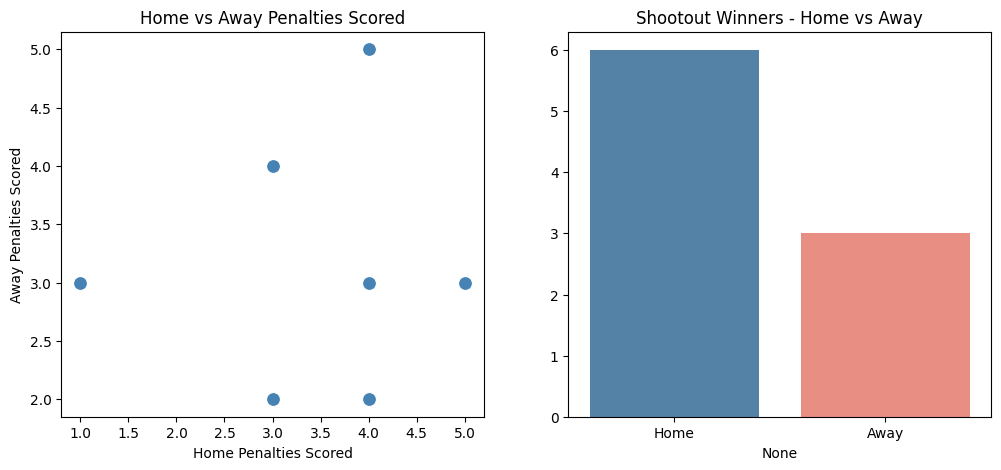

In [169]:
shootouts = df[(df['penalty_shootout'] == 'Yes (AET)') & (df['penalty_home'].notna())]
fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.scatterplot(data=shootouts, x='penalty_home', y='penalty_away', ax= axes[0], color='steelblue', s=100)
axes[0].set_title('Home vs Away Penalties Scored')
axes[0].set_xlabel('Home Penalties Scored')
axes[0].set_ylabel('Away Penalties Scored')
shootout_winner = shootouts.apply(lambda row: 'Home' if row['winner'] == row['home_team'] else 'Away', axis=1).value_counts()
sns.barplot(x=shootout_winner.index, y=shootout_winner.values, ax=axes[1], palette=['steelblue','salmon'])
axes[1].set_title('Shootout Winners - Home vs Away')
plt.show()

### Penalty Shootout Performance 
- Home teams won 6 shootouts compared to 3 for away teams — a 2x disparity
- Shootouts are fundamentally neutral tests of skill and nerve from a single spot
- This 2-to-1 success rate further suggests that bracket-assigned "home" teams are higher-seeded, theoretically superior squads
- In the scatter plot, home teams rarely bottom out, only scoring a single penalty in a shootout once
- Away teams hit a hard ceiling at 5 penalties scored, while home teams consistently hit the 3-to-5 range in successful shootouts